This analysis will attempt to determine if  planet mass, length of orbital semi-major axis, and number of stars contribute to eccentricity of orbit using NASA exoplanet archives. 

For Grading: 
(Just in case anything was difficult to find, I put together this lsit detailing where each of the elements meeting the project criteria are located!)

Requirement 0- Above
requirement 1- Cell 1
Requirement 2- Cell 2 (analysis of missing values)
Requirement 3- Cell 6
Requirement 4- Cell 6
Requirement 5- Cell 5 (vectorized operations), Cell 7 (Boolean Masking)
Requirement 6- Cell 7
Requirement 7- Cell 3 (scatterplots), Cell 4 (histograms)
Requirement 8- Cell 8, Cell 9

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

data_full = pd.read_csv('exoplanet_data_set.csv', skiprows = 39)



In [97]:
#Extracts relevant rows from full dataset and adds more descriptive column titles
data = data_full[['pl_name', 'sy_snum', 'discoverymethod', 'pl_orbper', 'pl_orbsmax', 'pl_bmassj', 'pl_orbeccen']]
data.columns = [['Planet Name', 'Number of Stars', 'Discovery Method', 'Orbital Period', 'Orbital Semi-Major Axis','Planet Mass (Jupiters)', 'Eccentricity']]

#Prints first five rows of data set
print(data.head())
print('-------------------------------------------------------------------------')

#Describes data shape
print(f"Data has shape {data.shape}: {data.shape[0]} rows and {data.shape[1]} columns")
print('-------------------------------------------------------------------------')

#Analysis of missing values
many_missing_values = 0
for column in data.columns: 
    #Iterates through each column of the data, counts missing values
    column_to_check = data[column]
    number_of_nans = column_to_check.isna().sum()
    #prints number of missing values
    print(f"{number_of_nans} missing values in column {column}")
    #Counts number of rows with more than 50% of their data missing
    if number_of_nans/len(data[column]) > 0.05:
        many_missing_values += 1

print('-------------------------------------------------------------------------')
print(f'Warning: {many_missing_values} columns with more than five percent of their data missing!')

#Removes rows with missing values
clean_data_0 = data.dropna()
#Selects only single-star  systems to analyze
clean_data_1 = clean_data_0[np.array(clean_data_0['Number of Stars']) == 1]
clean_data = clean_data_1.reset_index(drop = True)
print('-------------------------------------------------------------------------')
print(f"Cleaned data has shape {clean_data.shape}: {clean_data.shape[0]} rows and {clean_data.shape[1]} columns")





  Planet Name Number of Stars Discovery Method Orbital Period  \
0    11 Com b               2  Radial Velocity      323.21000   
1    11 Com b               2  Radial Velocity      326.03000   
2    11 Com b               2  Radial Velocity            NaN   
3    11 UMi b               1  Radial Velocity            NaN   
4    11 UMi b               1  Radial Velocity      516.21997   

  Orbital Semi-Major Axis Planet Mass (Jupiters) Eccentricity  
0                   1.178                 15.464        0.238  
1                   1.290                 19.400        0.231  
2                   1.210                 17.100          NaN  
3                   1.510                 10.800          NaN  
4                   1.530                 14.740        0.080  
-------------------------------------------------------------------------
Data has shape (39570, 7): 39570 rows and 7 columns
-------------------------------------------------------------------------
0 missing values in colum

Text(0.5, 1.0, 'Semi-Major Axis Length vs. Eccentricity')

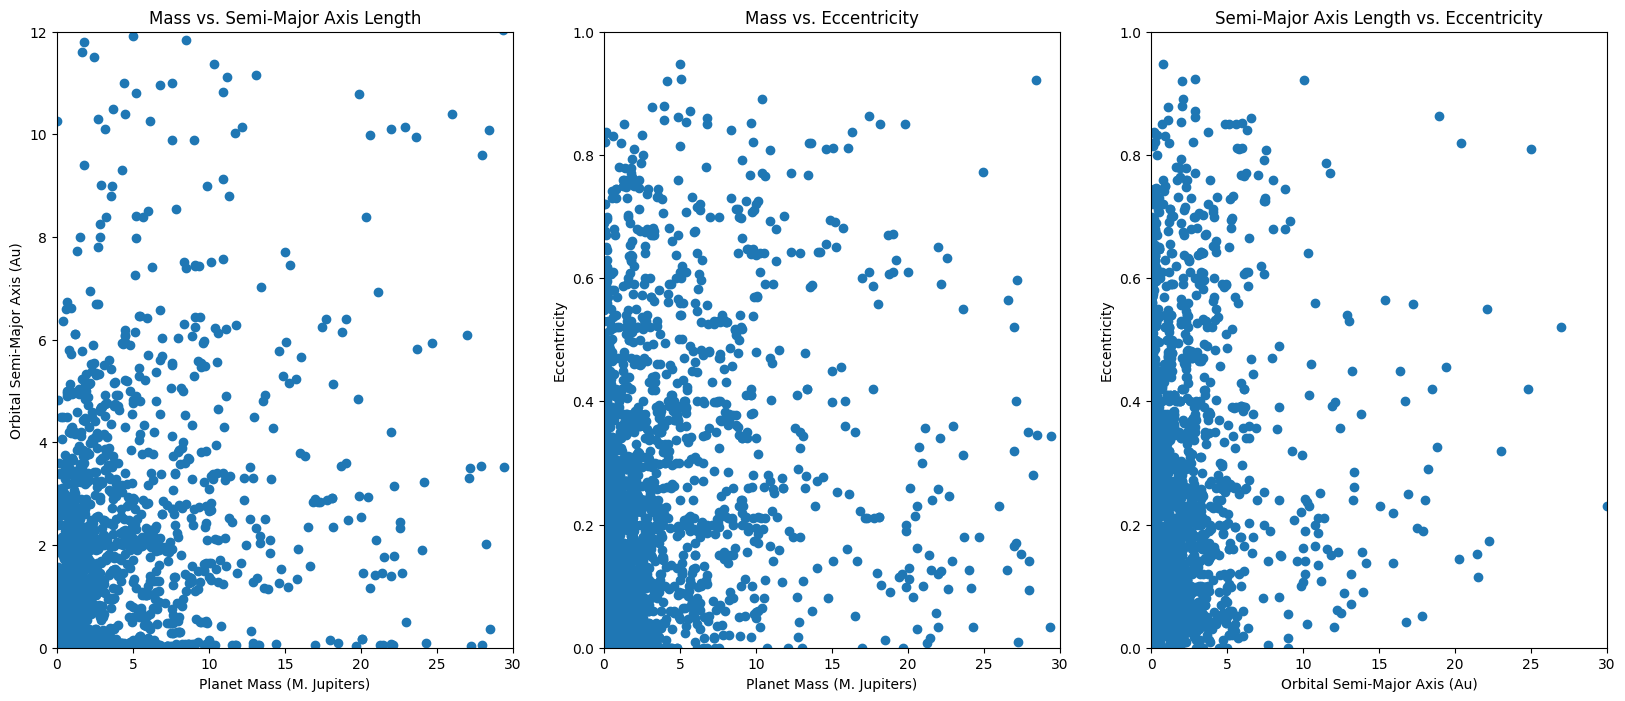

In [98]:
#Plots: scatter plot by discovery method, mass and orbital semi major axis

#An attempt to color points by the mothod of discovery that found the planet- unsucessful as of 4/23
'''clean_data['Discovery Method'] = clean_data['Discovery Method'].map({0:'Radial velocity', 1: 'Imaging', 2: 'Eclipse Timing Variations', 3: 'Microlensing',
             4:'Transit',5: 'Astrometry',6: 'Transit Timing Variations', 
             7: 'Orbital Brightness Modulation', 8: 'Pulsar Timing', 9: 'Pulsation Timing Variations'})
color_map = {'Radial velocity' : 'cornflowerblue', 'Imaging': 'forestgreen', 'Eclipse Timing Variations': 'darkblue', 'Microlensing': 'rebeccapurple',
             'Transit': 'slateblue', 'Astrometry': 'darkgreen', 'Transit Timing Variations': 'mediumpurple', 
             'Orbital Brightness Modulation' : 'seagreen', 'Pulsar Timing': 'deepskyblue', 'Pulsation Timing Variations': 'darkviolet'}
colors = clean_data['Discovery Method'].map(color_map)
'''
#Creates a figure with three sets of axes to plot each relationship
fig, ax = plt.subplots(1,3, figsize = (20,8))

#Plots any two columns as a scatter plot
ax[0].scatter(clean_data['Planet Mass (Jupiters)'], clean_data['Orbital Semi-Major Axis'])
#Sets the axes to show most of the data points
ax[0].set_xlim(0, 30)
ax[0].set_ylim(0, 12)
#Sets labels and titles
ax[0].set_xlabel('Planet Mass (M. Jupiters)')
ax[0].set_ylabel('Orbital Semi-Major Axis (Au)')
ax[0].set_title('Mass vs. Semi-Major Axis Length')

#Process repeated for other two relations

ax[1].scatter(clean_data['Planet Mass (Jupiters)'], clean_data['Eccentricity'])
ax[1].set_xlim(0, 30)
ax[1].set_ylim(0, 1)
ax[1].set_xlabel('Planet Mass (M. Jupiters)')
ax[1].set_ylabel('Eccentricity')
ax[1].set_title('Mass vs. Eccentricity')

ax[2].scatter(clean_data['Orbital Semi-Major Axis'], clean_data['Eccentricity'])
ax[2].set_xlim(0, 30)
ax[2].set_ylim(0, 1)
ax[2].set_xlabel('Orbital Semi-Major Axis (Au)')
ax[2].set_ylabel('Eccentricity')
ax[2].set_title('Semi-Major Axis Length vs. Eccentricity')



Text(0.5, 1.0, 'Eccentricity Histiogram')

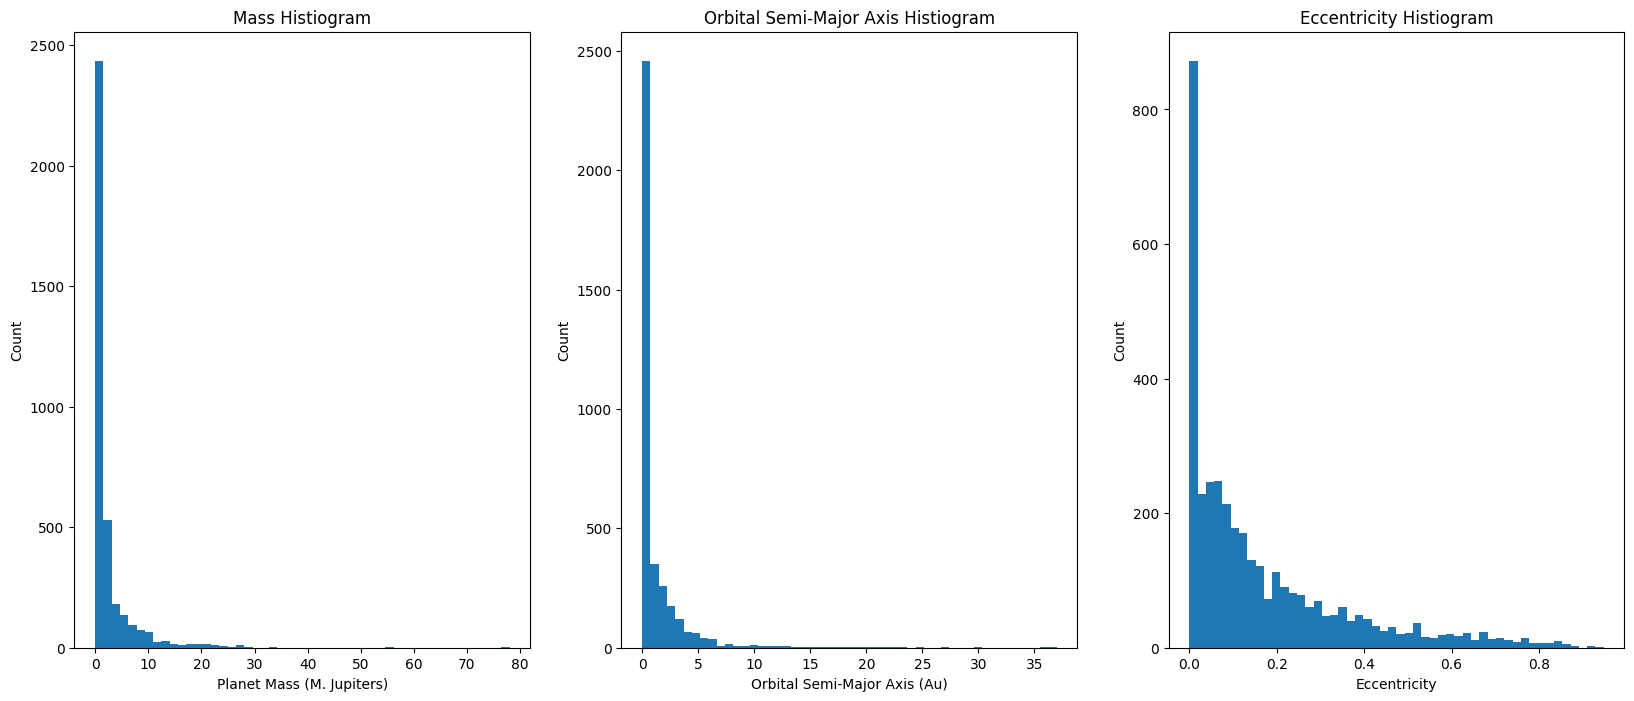

In [99]:
#Plots histiograms for each of the variables

fig, ax = plt.subplots(1,3, figsize = (20,8))

#Plots Planet Mass as a density histiogram
ax[0].hist(clean_data['Planet Mass (Jupiters)'], bins = 50)
#Sets labels and titles
ax[0].set_xlabel('Planet Mass (M. Jupiters)')
ax[0].set_ylabel('Count')
ax[0].set_title('Mass Histiogram')
#The distibution is not normally shaped, but heavily skewed towards planets around the size of Jupiter (sharp peak that falls quickly)

#Process repeated for eccentricity and orbital semi-major axis

ax[1].hist(clean_data['Orbital Semi-Major Axis'], bins = 50)
ax[1].set_xlabel('Orbital Semi-Major Axis (Au)')
ax[1].set_ylabel('Count')
ax[1].set_title('Orbital Semi-Major Axis Histiogram')
#The distribution is even less normally shaped, extremely skewed towards planets with very small axes

ax[2].hist(clean_data['Eccentricity'], bins = 50)
ax[2].set_xlabel('Eccentricity')
ax[2].set_ylabel('Count')
ax[2].set_title('Eccentricity Histiogram')
#The distribution shows the same trends as the previous two, with less eccentric orbits much more probable than more eccentric orbits. 


In [100]:
#Generates the mean values for mass, eccentricity, and orbital semi major axis

#Stores the columns containing mass, eccentricity, and semi-major axis into 1D numpy arrays
masses = np.array([clean_data['Planet Mass (Jupiters)']])
eccentricities = np.array([clean_data['Eccentricity']])
smaxes = np.array([clean_data['Orbital Semi-Major Axis']])

#Generates summaries of the data 
print(f"Data summary for Planet Masses   | Mean: {np.mean(masses):.4f} | Median: {np.median(masses):.4f} | Standard Deviation: {np.std(masses):.4f}")
print(f"Data summary for Eccentricity    | Mean: {np.mean(eccentricities):.4f} | Median: {np.median(eccentricities):.4f} | Standard Deviation: {np.std(eccentricities):.4f}")
print(f"Data summary for Semi-Major Axis | Mean: {np.mean(smaxes):.4f} | Median: {np.median(smaxes):.4f} | Standard Deviation: {np.std(smaxes):.4f}")



Data summary for Planet Masses   | Mean: 2.3402 | Median: 0.6985 | Standard Deviation: 4.4995
Data summary for Eccentricity    | Mean: 0.1672 | Median: 0.0988 | Standard Deviation: 0.1914
Data summary for Semi-Major Axis | Mean: 1.2308 | Median: 0.1375 | Standard Deviation: 2.6961


In [ ]:
#Function: summarize system
def summarise_planet(i):
    """
    Provides a summary of a given row in the data set, describing the system

    Arguments:
        i (int): the index of the row

    Returns:
        n/a (prints information directly to the screen)
    """
    system = clean_data.iloc[i]
    #Using the argument provided, locates the row of the dataset at the given index
    sys = {'pl_name': system.iloc[0], 'n_stars': system.iloc[1], 'disc_method': system.iloc[2], 'orbper': system.iloc[3], 'smax' : system.iloc[4], 'mass' : system.iloc[5], 'eccen': system.iloc[6]}
    #Enters the information from the data set into a dictionary
    print(f"Planet {sys['pl_name']}")
    #Prints the planet's name
    print("------------------------------------")
    #Provies a summary based on the planet's characteristics to help provide context for the system
    #IF-ELIF-ELSE BLOCK
    print(f"Planet {sys['pl_name']} was discovered using the {sys['disc_method']} method. It has an orbital period of {sys['orbper']} days!")
    if sys['smax'] > np.mean(smaxes):
        print(f"The semi-major axis of the planet is larger than average, with a value of {sys['smax']} Au, {(sys['smax']- np.mean(smaxes)):.2f} Au greater than the mean. ")
    elif sys['smax'] < np.mean(smaxes):
        print(f"The semi-major axis of the planet is smaller than average, with a value of {sys['smax']} Au, {(np.mean(smaxes) - sys['smax']):.2f} Au less than the mean. ")
    else:
        print(f"Congratulations! You have stumbled across a planet whose semi-major axis is exactly equal to the mean ({np.mean(smaxes)} Au). ")
    print(f"The planet has a mass of {sys['mass']} times the mass of Jupiter, or {sys['mass']*1.898e27} kilograms.")
    print(f"The planet has an eccentricity of {sys['eccen']}!")
    

#Picks a random planet to describe
summarise_planet(random.randint(1, 3680))

#Finds the indexes of the maximum values in each column
indexes_of_interest = clean_data.idxmax()

for index in indexes_of_interest:
    #Prints the planet summaries of the planets with the indexes of interest 
    summarise_planet(index)
    print("------------------------------------")


Planet HAT-P-51 b
------------------------------------
Planet HAT-P-51 b was discovered using the Transit method. It has an orbital period of 4.2180278 days!
The semi-major axis of the planet is smaller than average, with a value of 0.05067 Au, 1.18 Au less than the mean. 
The planet has a mass of 0.311 times the mass of Jupiter, or 5.9027799999999996e+26 kilograms.
The planet has an eccentricity of 0.07!
Planet xi Aql b
------------------------------------
Planet xi Aql b was discovered using the Radial Velocity method. It has an orbital period of 136.75 days!
The semi-major axis of the planet is smaller than average, with a value of 0.68 Au, 0.55 Au less than the mean. 
The planet has a mass of 2.8 times the mass of Jupiter, or 5.314399999999999e+27 kilograms.
The planet has an eccentricity of 0.0!
------------------------------------
Planet 11 UMi b
------------------------------------
Planet 11 UMi b was discovered using the Radial Velocity method. It has an orbital period of 516.2

Planets orbiting 1 star(s) had an average eccentricity of 0.1672331769021739
Planets orbiting 2 star(s) had an average eccentricity of 0.16710547361477573
Planets orbiting 3 star(s) had an average eccentricity of 0.17423910447761196


Text(0, 0.5, 'Average Eccentricity')

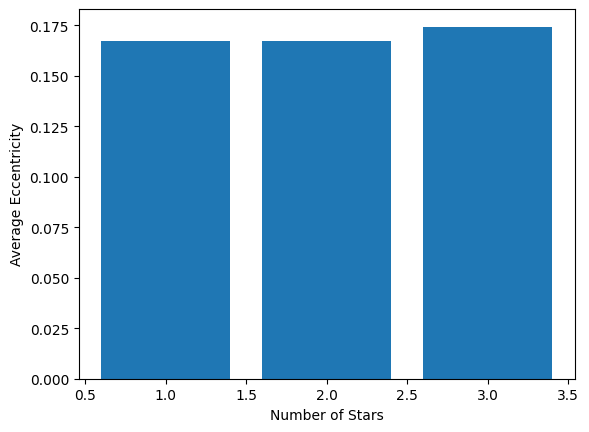

In [ ]:
#Determines the average eccentricity of planets orbiting around 1,2, or 3 stars

stars_to_eccentricities = {}
#Creates an empty dictionary to map number of stars to eccentricity

for i in range(1,4):
    #Even though there is one planet orbiting around a 4-star system, ommitted from this analysis due to lack of multiple data points
    i_stars = clean_data_0[np.array(clean_data_0['Number of Stars']) == i]
    #Filters the data set with NaN-containing rows removed but with multi-star systems included by number of stars
    av_eccentricity = np.mean(i_stars['Eccentricity'])
    #Sets the average eccentricity equal to the eccentricity of the selected rows
    stars_to_eccentricities[i] = av_eccentricity
    #Adds that eccentricity to the dictionary, with the key i (number of stars)

for key in stars_to_eccentricities.keys():
    #Prints the information stored in the dictionary for each key-value pair
    print(f"Planets orbiting {key} star(s) had an average eccentricity of {stars_to_eccentricities[key]}")

fig, ax = plt.subplots()
#Creates a graph to visually represent findings

categories = stars_to_eccentricities.keys()
values = stars_to_eccentricities.values()
#Defines categories and values based on the information contained in the dictionary

ax.bar(categories, values)
ax.set_xlabel("Number of Stars")
ax.set_ylabel("Average Eccentricity")
#Graphs data as a bar chart, adds labels to both axes

Correlation coefficient: 3140.7095554499824


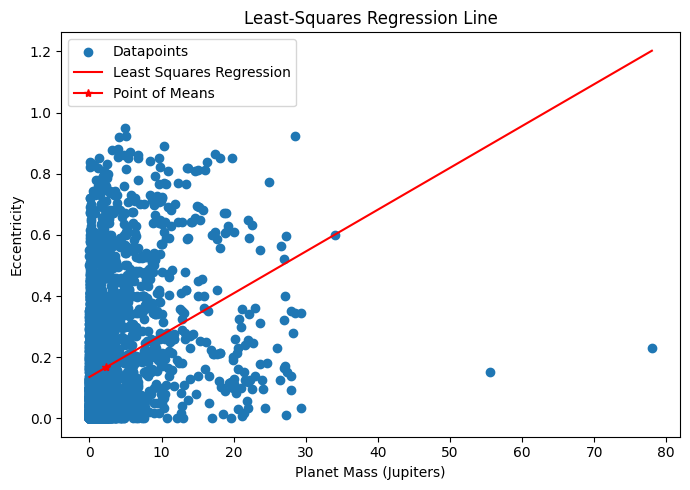

In [152]:
#Linear regression between mass and eccentricity

#Stores mass and eccentricity as x and y
x = clean_data['Planet Mass (Jupiters)'].values
y = clean_data['Eccentricity'].values

#Stores average mass and average eccentricity as x_bar and y_bar
x_bar = np.mean(x)
y_bar = np.mean(y)

#Calculates the variance and the covariance and squares variance
var_x = x - x_bar
var_y = y - y_bar
covar = var_x * var_y
var_x_squared = var_x * var_x

#Calculates beta1 and beta0 based on above calculations
beta1 = np.sum(covar)/np.sum(var_x_squared)
beta0 = y_bar - beta1*x_bar

#Calculates the x and y components of the line
x_line = np.linspace(x.min(), x.max(), 300)
y_line = beta1*x_line + beta0 

#Creates an axis to graph the datapoints and the regression line
fig, ax = plt.subplots(figsize=(7, 5))
#Prints the data points
ax.scatter(x,y, label = "Datapoints")
#Prints the regression line
ax.plot(x_line, y_line, color = 'red', label = "Least Squares Regression")
#Plots the point of means
ax.plot(x_bar, y_bar, marker = '*', color = 'red', label = "Point of Means")
#Labels the graph
ax.set_xlabel("Planet Mass (Jupiters)")
ax.set_ylabel("Eccentricity")
ax.set_title("Least-Squares Regression Line")
#Adds the legend and adjusts formatting
ax.legend()
plt.tight_layout()

#Calculates the values needed to find the correlation coefficient
ss_mean = np.sum((y - y_bar) ** 2)
var_mean = ss_mean / len(y)
ss_fit = np.sum((y - y_line) ** 2)
var_fit = ss_fit / len(y)

#Calculates the correlation coefficient
r_squared = (var_fit - var_mean) / var_mean

print(f"Correlation coefficient: {r_squared}")
#As the correlation coefficient is (much) greater than one, the linear regression fits worse than the line of means. 


Correlation coefficient: 1754.1019768818242


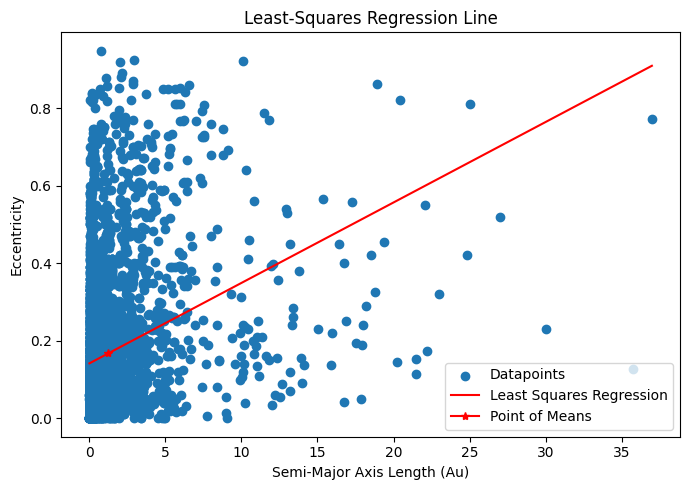

In [151]:
#Repeats the above process to find the regression line for semi-major axis and eccentricity

#Stores mass and eccentricity as x and y
x0 = clean_data['Orbital Semi-Major Axis'].values
y0 = clean_data['Eccentricity'].values

#Stores average mass and average eccentricity as x_bar and y_bar
x0_bar = np.mean(x0)
y0_bar = np.mean(y0)

#Calculates the variance and the covariance and squares variance
var_x0 = x0 - x0_bar
var_y0 = y0 - y0_bar
covar0 = var_x0 * var_y0
var_x0_squared = var_x0 * var_x0

#Calculates beta1 and beta0 based on above calculations
beta10 = np.sum(covar0)/np.sum(var_x0_squared)
beta00 = y0_bar - beta10*x0_bar

#Calculates the x and y components of the line
x0_line = np.linspace(x0.min(), x0.max(), 300)
y0_line = beta10*x0_line + beta00 

#Creates an axis to graph the datapoints and the regression line
fig, ax = plt.subplots(figsize=(7, 5))
#Prints the data points
ax.scatter(x0,y0, label = "Datapoints")
#Prints the regression line
ax.plot(x0_line, y0_line, color = 'red', label = "Least Squares Regression")
#Plots the point of means
ax.plot(x0_bar, y0_bar, marker = '*', color = 'red', label = "Point of Means")
#Labels the graph
ax.set_xlabel("Semi-Major Axis Length (Au)")
ax.set_ylabel("Eccentricity")
ax.set_title("Least-Squares Regression Line")
#Adds the legend and adjusts formatting
ax.legend()
plt.tight_layout()

#Calculates the values needed to find the correlation coefficient
ss_mean0 = np.sum((y0 - y0_bar) ** 2)
var_mean0 = ss_mean0 / len(y0)
ss_fit0 = np.sum((y0 - y0_line) ** 2)
var_fit0 = ss_fit0 / len(y0)

#Calculates the correlation coefficient
r_squared0 = (var_fit0 - var_mean0) / var_mean0

print(f"Correlation coefficient: {r_squared0}")
#As the correlation coefficient is (much) greater than one, the linear regression fits worse than the line of means. 